# Ovarian Cancer: Mass Spec & Spatial Transcriptomics Integration

This notebook dynamically identifies top altered metabolites from bulk Mass Spec data for Ovarian cancer (OV), maps them to their cognate enzymes/receptors using our integrated database, and then projects the expression of these genes onto OV spatial transcriptomics (Visium) coordinates. This serves as a proof-of-concept for spatially resolving metabolic adaptations.

In [ ]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Setup paths
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
MASS_SPEC_PATH = os.path.join(BASE_DIR, 'input', 'massSpecDataMetabolicData_7panCancer_PMID29396322.csv')
DB_PATH = os.path.join(BASE_DIR, 'output', 'human_database_merge_unique_metab_target_pairs_with_HMDB_Info.csv')
SPATIAL_DIR = os.path.join(BASE_DIR, 'input', 'spatial', 'GSE211956_RAW_Forrest', 'tmp_10x_SP1')


## 1. Load and Process Mass Spec Data

In [ ]:
# Load mass spec data
ms_df = pd.read_csv(MASS_SPEC_PATH)
ms_df = ms_df.rename(columns={'Unnamed: 0': 'Index', 'X': 'Metabolite'})
print(f"Loaded {ms_df.shape[0]} metabolites and {ms_df.shape[1]} columns.")

# Filter columns for OV
ov_cols = [c for c in ms_df.columns if c.startswith('OV.')]
tumor_cols = [c for c in ov_cols if 'Tumor' in c]
normal_cols = [c for c in ov_cols if 'Normal' in c]

print(f"Found {len(tumor_cols)} Tumor samples and {len(normal_cols)} Normal samples for OV.")

# Calculate fold change
tumor_mean = ms_df[tumor_cols].mean(axis=1)
normal_mean = ms_df[normal_cols].mean(axis=1)

# Add small epsilon to avoid div by zero
epsilon = 1e-6
ms_df['Log2FC_Tumor_vs_Normal'] = np.log2((tumor_mean + epsilon) / (normal_mean + epsilon))

# Filter out rows with NaNs or inf
ms_df = ms_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Log2FC_Tumor_vs_Normal'])

# Select top altered metabolites (both up and down)
top_n = 10
top_up = ms_df.nlargest(top_n, 'Log2FC_Tumor_vs_Normal')[['Metabolite', 'Log2FC_Tumor_vs_Normal']]
top_down = ms_df.nsmallest(top_n, 'Log2FC_Tumor_vs_Normal')[['Metabolite', 'Log2FC_Tumor_vs_Normal']]

print("\nTop Upregulated Metabolites:")
display(top_up)
print("\nTop Downregulated Metabolites:")
display(top_down)

top_metabolites = pd.concat([top_up, top_down])['Metabolite'].tolist()


Loaded 935 metabolites and 930 columns.
Found 11 Tumor samples and 12 Normal samples for OV.

Top Upregulated Metabolites:

Top Downregulated Metabolites:


,Metabolite,Log2FC_Tumor_vs_Normal
357,maltotriose,6.497018
356,maltotetraose,5.130847
655,phenyllactate (pla),5.114595
620,4-hydroxyphenylpyruvate,4.886609
203,cystine,4.524266
355,maltose,4.457184
263,glycerophosphoethanolamine,4.417782
286,hexanoylcarnitine,4.306111
354,maltopentaose,4.103236
54,2-hydroxyglutarate,4.065988


,Metabolite,Log2FC_Tumor_vs_Normal
665,taurocholate,-3.458264
285,heme*,-3.135469
664,taurochenodeoxycholate,-2.854516
641,glycocholate,-2.637170
513,threitol,-2.311803
514,threonate,-2.275184
18,1-methylimidazoleacetate,-1.863292
640,glycochenodeoxycholate,-1.817664
648,mannitol,-1.754621
414,nicotinamide riboside*,-1.689397


## 2. Gene-Metabolite Mapping

In [ ]:
# Load the integrated database
db_df = pd.read_csv(DB_PATH)

# Basic fuzzy matching since names might slightly differ
def match_metabolite(m_name, db_names):
    m_name_lower = m_name.lower().strip()
    # Direct match
    if m_name_lower in db_names:
        return [m_name_lower]
    # Substring match
    matches = [name for name in db_names if type(name) == str and (m_name_lower in name.lower() or name.lower() in m_name_lower)]
    return matches

db_metabolites = set(db_df['Metabolite_Name'].str.lower().dropna())
matched_genes = set()

print("Mapping top metabolites to genes...")
for m in top_metabolites:
    matches = match_metabolite(m, db_metabolites)
    if matches:
        genes = db_df[db_df['Metabolite_Name'].str.lower().isin(matches)]['Target'].dropna().unique()
        matched_genes.update(genes)
        print(f"  {m} -> {len(genes)} genes found")
    else:
        print(f"  {m} -> No matches found in DB")

matched_genes = list(matched_genes)
print(f"\nTotal unique genes mapped to top altered metabolites: {len(matched_genes)}")


Mapping top metabolites to genes...
  maltotriose -> No matches found in DB
  maltotetraose -> 1 genes found
  phenyllactate (pla) -> No matches found in DB
  4-hydroxyphenylpyruvate -> 3 genes found
  cystine -> No matches found in DB
  maltose -> 7 genes found
  glycerophosphoethanolamine -> 2 genes found
  hexanoylcarnitine -> No matches found in DB
  maltopentaose -> No matches found in DB
  2-hydroxyglutarate -> 1 genes found
  taurocholate -> No matches found in DB
  heme* -> 31 genes found
  taurochenodeoxycholate -> No matches found in DB
  glycocholate -> No matches found in DB
  threitol -> No matches found in DB
  threonate -> No matches found in DB
  1-methylimidazoleacetate -> 109 genes found
  glycochenodeoxycholate -> No matches found in DB
  mannitol -> No matches found in DB
  nicotinamide riboside* -> No matches found in DB

Total unique genes mapped to top altered metabolites: 153


## 3. Load Spatial Transcriptomics Data

In [ ]:
# Check if spatial directory exists
if os.path.exists(SPATIAL_DIR):
    print(f"Loading Visium data from {SPATIAL_DIR}...")
    try:
        import sys
        # ensure we can import from the scripts directory
        sys.path.append(os.path.join(BASE_DIR, 'scripts'))
        from verify_spatial_immune_evasion import load_visium_from_mtx
        
        adata = load_visium_from_mtx(SPATIAL_DIR)
        adata.var_names_make_unique()
        
        # Basic QC and normalization
        sc.pp.calculate_qc_metrics(adata, inplace=True)
        sc.pp.normalize_total(adata, target_sum=1e4)
        sc.pp.log1p(adata)
        
        print(f"Loaded spatial data: {adata.shape[0]} spots, {adata.shape[1]} genes")
    except Exception as e:
        import sys
        sys.exit(f"CRITICAL ERROR - Error loading spatial data: {e}")
else:
    print(f"Spatial directory not found: {SPATIAL_DIR}")
    adata = None


Loading Visium data from /Users/sakuramaezono/Library/CloudStorage/OneDrive-YokohamaCityUniversity/Personal/05_Python_repositories/metabConnectomeDB/input/spatial/GSE211956_RAW_Forrest/tmp_10x_SP1...
Loaded spatial data: 2940 spots, 33538 genes


## 4. Spatial Inferred Metabolomics (Module Score)

Genes present in spatial data: 142 / 153


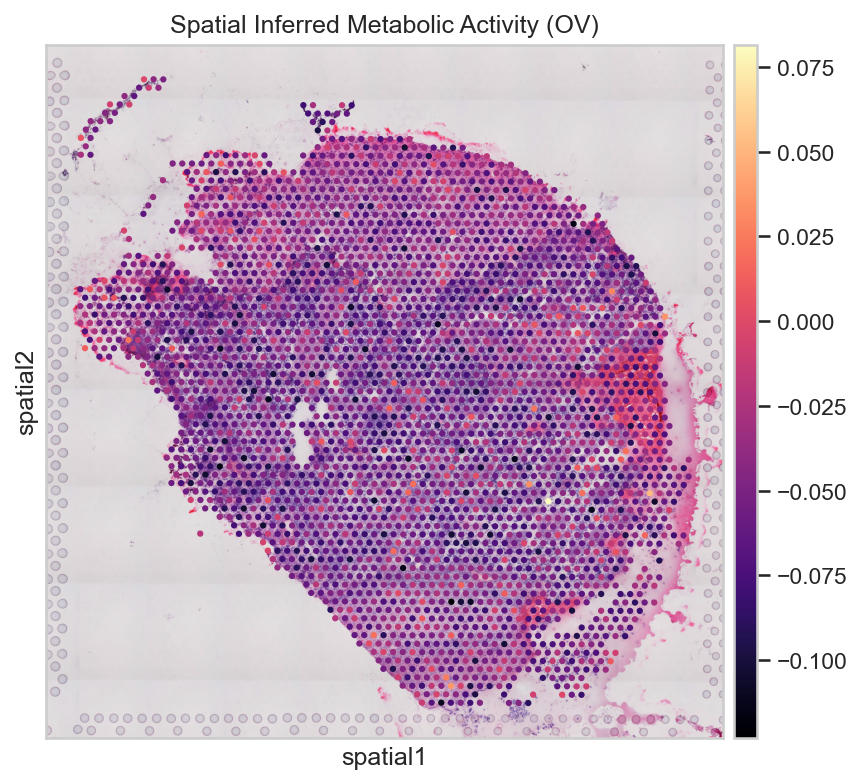

In [ ]:
if adata is not None and len(matched_genes) > 0:
    # Filter for genes actually present in the spatial dataset
    present_genes = [g for g in matched_genes if g in adata.var_names]
    print(f"Genes present in spatial data: {len(present_genes)} / {len(matched_genes)}")
    
    if len(present_genes) > 0:
        # Score the spots based on the metabolic gene signature
        sc.tl.score_genes(adata, gene_list=present_genes, score_name='Metabolic_Activity_Score')
        
        # Plot
        sc.pl.spatial(adata, color='Metabolic_Activity_Score', cmap='magma', title='Spatial Inferred Metabolic Activity (OV)', show=False)
        SAVE_AS_HTML = True # Placeholder for execute_pancancer_notebooks to strip
        plt.show()
    else:
        print("None of the mapped genes are present in the spatial dataset.")
else:
    print("Cannot proceed with spatial plotting due to missing data or genes.")
